In [1]:
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.visualization import simple_norm
from spectral_cube import SpectralCube as sc
from tqdm import trange

from pybaselines import Baseline
from pybaselines.utils import gaussian, relative_difference
from pybaselines._banded_utils import PenalizedSystem
from pybaselines._weighting import _arpls

from joblib import Parallel, delayed
from functools import partial

# disable the Parameter Warning
import warnings
from pybaselines.utils import ParameterWarning
warnings.filterwarnings("ignore", category=ParameterWarning)

%matplotlib widget

In [2]:
# Define RA ranges and signs
pattern = "./South/Combined/CRAFTS_RA{ra}_DEC-13_2.fits"
ra_ranges = ["60_80", "80_100", "100_120", "120_140"]
ra_i = 3  # Change this index to select different RA ranges
ra = ra_ranges[ra_i]

# Original file
file = pattern.format(ra=ra)

# Baseline corrected file
corrected_path = "./South/Baseline Corrected/"
corrected_name = f"CRAFTS_RA{ra}_DEC-13_2"

corrected_file_minus = f"{corrected_path}{corrected_name}_cor_-.fits"
corrected_file_plus = f"{corrected_path}{corrected_name}_cor_+.fits"

print(f"Original file: {file}")
print(f"Minus corrected file: {corrected_file_minus}")
print(f"Plus corrected file: {corrected_file_plus}")

# Velocity ranges
vel_minus = np.array([[-55, -255], [-58, -258], [-60, -260], [-61, -261]])
vel_plus = np.array([[83, 283], [114, 314], [132, 332], [139, 339]])

Original file: ./South/Combined/CRAFTS_RA120_140_DEC-13_2.fits
Minus corrected file: ./South/Baseline Corrected/CRAFTS_RA120_140_DEC-13_2_cor_-.fits
Plus corrected file: ./South/Baseline Corrected/CRAFTS_RA120_140_DEC-13_2_cor_+.fits


In [3]:
cube = sc.read(file).with_spectral_unit(u.km / u.s)
data = cube.unmasked_data[:, :, :].value
n_v, n_y, n_x = data.shape

cube_minus = cube.spectral_slab(vel_minus[ra_i,0] * u.km / u.s, vel_minus[ra_i,1] * u.km / u.s)
cube_plus = cube.spectral_slab(vel_plus[ra_i,0] * u.km / u.s, vel_plus[ra_i,1] * u.km / u.s)

In [4]:
# Data with negative velocities
data_minus = cube_minus.unmasked_data[:, :, :].value
data_minus = np.nan_to_num(data_minus)

n_v_minus, n_y_minus, n_x_minus = data_minus.shape

velocities_minus = cube_minus.spectral_axis.value
cube_minus

SpectralCube with shape=(994, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:   120.012500 deg:  139.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:    994  type_s: VRAD      unit_s: km / s  range:     -260.936 km / s:     -61.061 km / s

In [5]:
# Data with positive velocities
data_plus = cube_plus.unmasked_data[:, :, :].value
data_plus = np.nan_to_num(data_plus)

n_v_plus, n_y_plus, n_x_plus = data_plus.shape

velocities_plus = cube_plus.spectral_axis.value
cube_plus

SpectralCube with shape=(995, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:   120.012500 deg:  139.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:    995  type_s: VRAD      unit_s: km / s  range:      139.015 km / s:     339.091 km / s

In [6]:
def masked_arpls(y, mask=None, lam=1e8, diff_order=2, tol=1e-3, max_iter=50, weights=None):
    """A mask-aware version of the arpls algorithm."""
    len_y = len(y)
    if mask is None:
        mask = np.ones(len_y, dtype=bool)
        y_fit = y
    else:
        y_fit = 1 * y  # don't want to override the input y, so make a copy
        y_fit[~mask] = 0  # cover that case of nan values in y since 0 * nan = nan rather than 0
    if weights is None:
        weights = np.ones(len_y)
    else:
        weights = 1 * weights  # don't want to override the input weights, so make a copy
    weights[~mask] = 0
    whittaker_system = PenalizedSystem(len(y), lam=lam, diff_order=diff_order)
    for _ in range(max_iter):
        baseline = whittaker_system.solve(
            whittaker_system.add_diagonal(weights), weights * y_fit,
        )
        # need to ignore the problem regions in y since they would otherwise affect
        # the arpls weighting; could alternatively do:
        # _arpls(np.interp(x, x[mask], y[mask]), baseline) to approximate
        # the y-values, but it leads to a slightly different result
        calc_weights, exit_early = _arpls(y[mask], baseline[mask])
        if exit_early:
            break
        new_weights = np.zeros(len_y)
        new_weights[mask] = calc_weights
        if relative_difference(weights, new_weights) < tol:
            break
        weights = new_weights
    return baseline

0.00739067 0.099812046


Text(0.5, 0.98, 'Baseline Fitting: ARPLS (RA/Dec=125.863 6.2125)')

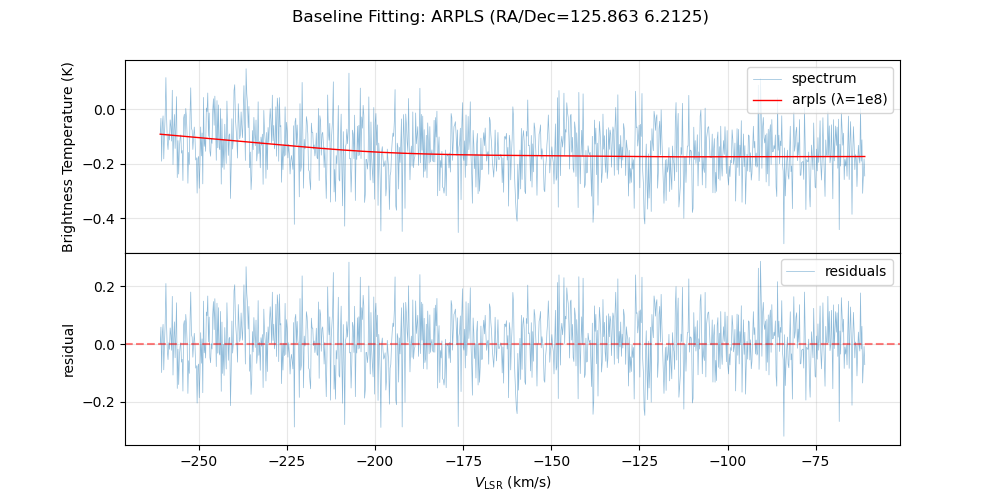

In [7]:
random_x, random_y = np.random.randint(0, n_x_minus), np.random.randint(0, n_y_minus)
spectrum = data_minus[:, random_y, random_x]
sky = cube.wcs.celestial.pixel_to_world(random_y, random_x)
# print(sky)

bkg, params = Baseline(velocities_minus).arpls(spectrum, lam=1e8)
residuals = spectrum - bkg
print(np.mean(residuals), np.std(residuals))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={'hspace': 0})

ax1.plot(velocities_minus, spectrum, label='spectrum', lw=0.5, alpha=0.5)
ax1.plot(velocities_minus, bkg, label='arpls (λ=1e8)', lw=1, color='red')
ax1.set_ylabel('Brightness Temperature (K)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelbottom=False)

ax2.plot(velocities_minus, residuals, label='residuals', lw=0.5, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.set_xlabel(r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$')
ax2.set_ylabel('residual')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# 添加标题
plt.suptitle(f'Baseline Fitting: ARPLS (RA/Dec={sky.to_string('decimal')})')

In [8]:
# Reshape data to 2D array for parallel processing
# Every row is a spectrum
dataset_minus = data_minus.transpose(1, 2, 0).reshape(n_y_minus * n_x_minus, n_v_minus)  # shape (480000, len(velocities))
baseline_fitter_minus = Baseline(x_data=velocities_minus)

def fit_baseline_parallel(i, baseline_fitter, y_data):
    bkg, params = baseline_fitter.arpls(y_data[i], lam=1e8)
    return bkg

# Parallel computation
results_minus = Parallel(n_jobs=-1, backend="loky", return_as="generator")(
    delayed(fit_baseline_parallel)(i, baseline_fitter_minus, dataset_minus)
    for i in trange(len(dataset_minus))
)

# Turn the generator into a numpy array
baselines_minus = np.array(list(results_minus))
baselines_minus.shape

  0%|          | 48/480000 [00:00<1:49:12, 73.24it/s]/home/firestar/.miniforge/lib/python3.13/site-packages/pybaselines/whittaker.py:327: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
  new_weights, exit_early = _weighting._arpls(y, baseline)
/home/firestar/.miniforge/lib/python3.13/site-packages/pybaselines/whittaker.py:327: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
  new_weights, exit_early = _weighting._arpls(y, baseline)
/home/firestar/.miniforge/lib/python3.13/site-packages/pybaselines/whittaker.py:327: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
  new_weights, exit_early = _weighting._arpls(y, baseline)
/home/firestar/.miniforge/lib/python3.13/site-packages/pybaselines/whittaker.py:327: ParameterWarning: almost all baseline points a

(480000, 994)

In [9]:
# Reshape data to 2D array for parallel processing
# Every row is a spectrum
dataset_plus = data_plus.transpose(1, 2, 0).reshape(n_y_plus * n_x_plus, n_v_plus)  # shape (480000, len(velocities))
baseline_fitter_plus = Baseline(x_data=velocities_plus)

def fit_baseline_parallel(i, baseline_fitter, y_data):
    bkg, params = baseline_fitter.arpls(y_data[i], lam=1e8)
    return bkg

# Parallel computation
results_plus = Parallel(n_jobs=-1, backend="loky", return_as="generator")(
    delayed(fit_baseline_parallel)(i, baseline_fitter_plus, dataset_plus)
    for i in trange(len(dataset_plus))
)

# Turn the generator into a numpy array
baselines_plus = np.array(list(results_plus))
baselines_plus.shape

100%|██████████| 480000/480000 [00:08<00:00, 58999.54it/s]


(480000, 995)

In [10]:
baselines_minus = baselines_minus.T.reshape(n_v_minus, n_y_minus, n_x_minus)
baselines_cube_minus = sc(data=baselines_minus * u.K, wcs=cube_minus.wcs)
baselines_cube_minus

corrected_minus = data_minus - baselines_minus
corrected_minus *= u.K
corrected_cube_minus = sc(data=corrected_minus, wcs=cube_minus.wcs)
corrected_cube_minus

SpectralCube with shape=(994, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:   120.012500 deg:  139.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:    994  type_s: VRAD      unit_s: m / s  range:  -260935.598 m / s:  -61060.989 m / s

In [11]:
baselines_plus = baselines_plus.T.reshape(n_v_plus, n_y_plus, n_x_plus)
baselines_cube_plus = sc(data=baselines_plus * u.K, wcs=cube_plus.wcs)
baselines_cube_plus

corrected_plus = data_plus - baselines_plus
corrected_plus *= u.K
corrected_cube_plus = sc(data=corrected_plus, wcs=cube_plus.wcs)
corrected_cube_plus

SpectralCube with shape=(995, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:   120.012500 deg:  139.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:    995  type_s: VRAD      unit_s: m / s  range:   139014.904 m / s:  339090.798 m / s

In [12]:
import inspect

def displayimage(cube, region=None):
    img = cube.moment(order=0).value  # moment 0
    fig, ax = plt.subplots(
        figsize=(5, 3),
        layout="compressed",
        subplot_kw={"projection": cube.wcs.celestial},
    )
    norm = simple_norm(np.array(img), min_percent=5, max_percent=95, stretch="linear")
    im = ax.imshow(img, norm=norm, cmap="viridis", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    if region != None:
        region.plot(color="white")
    plt.colorbar(im)

    # 获取cube的变量名
    try:
        frame = inspect.currentframe().f_back
        cube_varname = None
        for name, obj in frame.f_locals.items():
            if obj is cube:
                cube_varname = name
                break
        if cube_varname:
            plt.title(f"Cube: {cube_varname}")
        else:
            plt.title("Cube Image")
    except:
        plt.title("Cube Image")

    plt.show()

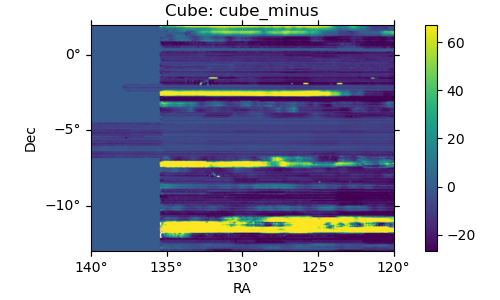

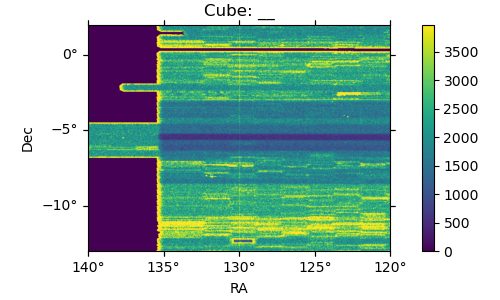

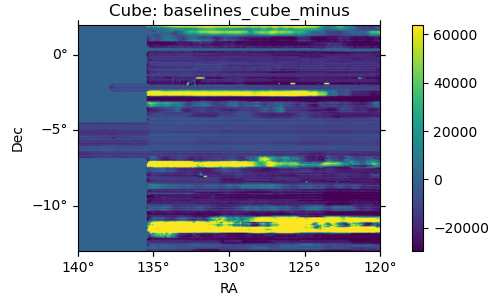

In [13]:
displayimage(cube_minus)
displayimage(corrected_cube_minus)
displayimage(baselines_cube_minus)

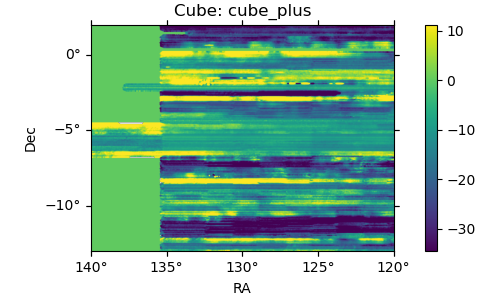

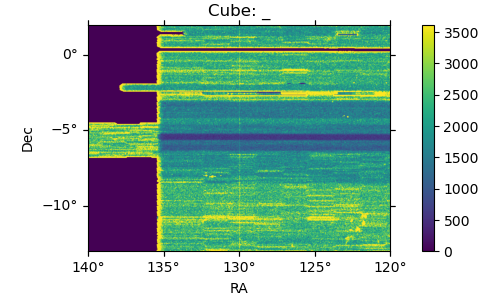

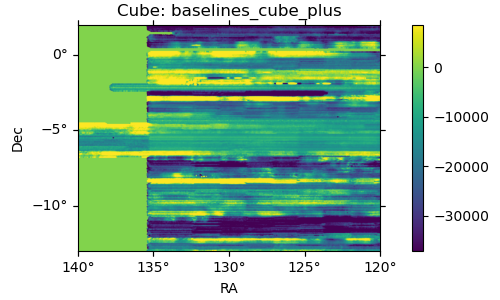

In [14]:
displayimage(cube_plus)
displayimage(corrected_cube_plus)
displayimage(baselines_cube_plus)

In [15]:
# Save the corrected cube to a new FITS file
corrected_cube_minus.write(corrected_file_minus, overwrite=True)
corrected_cube_plus.write(corrected_file_plus, overwrite=True)